## 1. Experimental Environment and Data Access

The experiment is conducted in the Kaggle environment using the Galaxy Zoo 2 dataset and the ResNet50 architecture. The required Python libraries, reproducibility settings, and data locations are established before dataset construction and model training. The computational setup is kept consistent throughout the experiment.

In [37]:
!pip -q install --upgrade gdown

import os
import random
import time
import zipfile
from pathlib import Path

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from tensorflow.keras import layers
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

GPUS = tf.config.list_physical_devices('GPU')
for gpu in GPUS:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

if GPUS:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')

if os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
    ROOT = Path('/kaggle/working/GalaxyZoo_ResNet50_Clean')
else:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        ROOT = Path('/content/drive/MyDrive/GalaxyZoo_ResNet50_Clean')
    except (ImportError, NotImplementedError):
        ROOT = Path('/kaggle/working/GalaxyZoo_ResNet50_Clean')

DATA_DIR = ROOT / 'data'
IMAGE_ROOT = ROOT / 'images_gz2'
IMAGE_FOLDER = IMAGE_ROOT / 'images'
RESULTS_DIR = ROOT / 'results_7782'

for folder in (DATA_DIR, RESULTS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print('=' * 72)
print('GALAXY ZOO 2 — RESNET50 IMPROVED PIPELINE')
print('=' * 72)
print('TensorFlow:', tf.__version__)
print('GPU(s):', GPUS if GPUS else 'No GPU detected')
print('Precision policy:', tf.keras.mixed_precision.global_policy())
print('Workspace:', ROOT)


GALAXY ZOO 2 — RESNET50 IMPROVED PIPELINE
TensorFlow: 2.20.0
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Precision policy: <DTypePolicy "mixed_float16">
Workspace: /kaggle/working/GalaxyZoo_ResNet50_Clean


## 2. Galaxy Zoo 2 Data Sources

Galaxy Zoo 2 metadata provide the connection between galaxy identifiers, image assets, and human-derived morphological classifications. The filename mapping and Hart16 metadata are used together to construct the image-level dataset. Explicit paths provide a reproducible link between the source data and the classification pipeline.

In [2]:
MAPPING_PATH = DATA_DIR / 'gz2_filename_mapping.csv'
HART_PATH = DATA_DIR / 'gz2_hart16.csv.gz'
ZIP_PATH = DATA_DIR / 'images_gz2.zip'

downloads = {
    MAPPING_PATH: '1KPJdI9yEIOOEk-sfSkCM7zqSgjBPPTZW',
    HART_PATH: '1mCLcfimm3CoOisewRq0ljNp_jKjZpoHc',
    ZIP_PATH: '1boMM-XQ_EmQa3Rb5abZXSKNItDD9hLF8',
}

for path, file_id in downloads.items():
    if not path.exists():
        print(f'Downloading {path.name} ...')
        gdown.download(id=file_id, output=str(path), quiet=False)
    else:
        print(f'Found: {path.name}')

if not IMAGE_FOLDER.exists():
    print('Extracting image archive ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as archive:
        archive.extractall(IMAGE_ROOT)
else:
    print('Image folder already exists; full re-extraction skipped.')

Downloading...
From: https://drive.google.com/uc?id=1KPJdI9yEIOOEk-sfSkCM7zqSgjBPPTZW
To: /kaggle/working/GalaxyZoo_ResNet50_Clean/data/gz2_filename_mapping.csv
100%|██████████| 13.2M/13.2M [00:00<00:00, 83.6MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1mCLcfimm3CoOisewRq0ljNp_jKjZpoHc
From (redirected): https://drive.google.com/uc?id=1mCLcfimm3CoOisewRq0ljNp_jKjZpoHc&confirm=t&uuid=10d0f41b-73c0-4b54-9581-ea56520c6f49
To: /kaggle/working/GalaxyZoo_ResNet50_Clean/data/gz2_hart16.csv.gz
100%|██████████| 78.5M/78.5M [00:00<00:00, 103MB/s] 


Downloading...
From (original): https://drive.google.com/uc?id=1boMM-XQ_EmQa3Rb5abZXSKNItDD9hLF8
From (redirected): https://drive.google.com/uc?id=1boMM-XQ_EmQa3Rb5abZXSKNItDD9hLF8&confirm=t&uuid=a09b6f7b-65ac-405e-a241-667b07a690d6
To: /kaggle/working/GalaxyZoo_ResNet50_Clean/data/images_gz2.zip
100%|██████████| 3.35G/3.35G [00:34<00:00, 97.8MB/s]


Extracting image archive ...


## 3. Galaxy Zoo 2 Metadata Loading and Inspection

The Galaxy Zoo 2 mapping and Hart16 metadata are loaded for dataset construction. Their dimensions and representative information provide an initial verification of the available records and fields. These metadata form the basis for assigning high-confidence morphology labels to individual galaxy images.

In [3]:
mapping = pd.read_csv(MAPPING_PATH)
hart = pd.read_csv(HART_PATH)

print("Mapping shape:", mapping.shape)
print("Hart shape:", hart.shape)

display(mapping.head())
display(hart.head())

print("Mapping columns:")
print(mapping.columns.tolist())

print("\nHart columns:")
print(hart.columns.tolist())

mapping["objid"] = pd.to_numeric(mapping["objid"], errors="coerce").astype("Int64")
hart["dr7objid"] = pd.to_numeric(hart["dr7objid"], errors="coerce").astype("Int64")

merged = mapping.merge(
    hart,
    left_on="objid",
    right_on="dr7objid",
    how="inner",
    validate="many_to_one",
)

df = merged.copy()
df["asset_id"] = pd.to_numeric(df["asset_id"], errors="coerce")
df = df.dropna(subset=["asset_id"]).copy()
df["asset_id"] = df["asset_id"].astype("int64")

print("Merged shape:", df.shape)
display(df[["objid", "asset_id", "gz2_class"]].head(10))


Mapping shape: (355990, 3)
Hart shape: (239695, 231)


,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3
3,587722981741363323,original,4
4,587722981741559888,original,5


,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0


Mapping columns:
['objid', 'sample', 'asset_id']

Hart columns:
['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count', 't01_smooth_or_features_a01_smooth_weight', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a01_smooth_flag', 't01_smooth_or_features_a02_features_or_disk_count', 't01_smooth_or_features_a02_features_or_disk_weight', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a02_features_or_disk_weighted_fraction', 't01_smooth_or_features_a02_features_or_disk_debiased', 't01_smooth_or_features_a02_features_or_disk_flag', 't01_smooth_or_features_a03_star_or_artifact_count', 't01_smooth_or_features_a03_star_or_artifact_weight', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't01_smooth_or_features_a03_star_or_artifact_we

,objid,asset_id,gz2_class
0,587722981741363294,3,Sb
1,587722981741363323,4,Sc?l
2,587722981741559888,5,Er
3,587722981741625481,6,Sc1t
4,587722981741625484,7,Sb
5,587722981741625520,8,Ei
6,587722981741625545,9,Er
7,587722981741756545,11,Sb
8,587722981741756579,12,SBc
9,587722981741822057,13,Ec


## 4. High-Confidence Morphology Label Construction

Galaxy morphology labels are derived from weighted Galaxy Zoo 2 classification fractions using a confidence threshold of 0.80. The resulting categories are elliptical, spiral, and irregular, with ambiguous records excluded when multiple class conditions are satisfied. This procedure produces a higher-confidence three-class classification target for the subsequent experiments.

In [ ]:
THRESHOLD = 0.80

required_columns = [
    "t01_smooth_or_features_a01_smooth_weighted_fraction",
    "t01_smooth_or_features_a02_features_or_disk_weighted_fraction",
    "t04_spiral_a08_spiral_weighted_fraction",
    "t08_odd_feature_a22_irregular_weighted_fraction",
]
missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise KeyError(f"Missing columns in the Hart CSV: {missing_columns}")

elliptical_mask = (
    df["t01_smooth_or_features_a01_smooth_weighted_fraction"] >= THRESHOLD
)

spiral_mask = (
    (df["t01_smooth_or_features_a02_features_or_disk_weighted_fraction"] >= THRESHOLD)
    & (df["t04_spiral_a08_spiral_weighted_fraction"] >= THRESHOLD)
)

irregular_mask = (
    df["t08_odd_feature_a22_irregular_weighted_fraction"] >= THRESHOLD
)

candidate_count = (
    elliptical_mask.astype("int8")
    + spiral_mask.astype("int8")
    + irregular_mask.astype("int8")
)

df["label"] = pd.NA
df.loc[elliptical_mask & (candidate_count == 1), "label"] = "elliptical"
df.loc[spiral_mask & (candidate_count == 1), "label"] = "spiral"
df.loc[irregular_mask & (candidate_count == 1), "label"] = "irregular"

print("Overlapping high-confidence rows removed:", int((candidate_count > 1).sum()))

df = df.dropna(subset=["label"]).copy()
print(df["label"].value_counts())


Overlapping high-confidence rows removed: 4486
label
elliptical    103196
spiral         22780
irregular       3296
Name: count, dtype: int64


## 5. Image Availability and Dataset Balancing

The labeled metadata are matched against the available galaxy image assets before model development. An equal number of samples is selected for each morphology class, producing a balanced dataset for comparative evaluation. The fixed random seed preserves reproducibility of the sampling procedure.

In [ ]:
available_image_ids = {p.stem for p in IMAGE_FOLDER.glob("*.jpg")}

df_with_images = df[
    df["asset_id"].astype(str).isin(available_image_ids)
].copy()

available_counts = df_with_images["label"].value_counts()
missing_classes = {"elliptical", "spiral", "irregular"} - set(available_counts.index)
if missing_classes:
    raise ValueError(f"Classes with no samples containing images: {missing_classes}")

N_PER_CLASS = int(available_counts.min())
if N_PER_CLASS < 1000:
    print("WARNING: The smallest class has fewer than 1000 samples; the 80% target may be more challenging.")

balanced_df = pd.concat(
    [
        group.sample(n=N_PER_CLASS, random_state=SEED)
        for _, group in df_with_images.groupby("label", sort=True)
    ],
    ignore_index=True,
)

balanced_df = balanced_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Available before balancing:")
print(available_counts)
print()
print("Balanced:")
print(balanced_df["label"].value_counts())
print()
print("Total images:", len(balanced_df))


Available before balancing:
label
elliptical    103173
spiral         22779
irregular       3295
Name: count, dtype: int64

Balanced:
label
irregular     3295
elliptical    3295
spiral        3295
Name: count, dtype: int64

Total images: 9885


## 6. Three-Class Dataset Organization

The selected galaxy images are organized into class-specific directories corresponding to elliptical, spiral, and irregular morphology. This structure provides the directory-based input required by the TensorFlow data pipeline while preserving the balanced sample selection. The resulting image counts document the final set of assets available for the experiment.

In [ ]:
import shutil
from pathlib import Path

THREE_CLASS_DIR = Path("/kaggle/working/three_class_data")

assert IMAGE_FOLDER.is_dir()
print("Images will be read directly from Kaggle Input:", IMAGE_FOLDER)

classes = ["elliptical", "spiral", "irregular"]

if THREE_CLASS_DIR.exists():
    shutil.rmtree(THREE_CLASS_DIR)

for cls in classes:
    (THREE_CLASS_DIR / cls).mkdir(parents=True, exist_ok=True)

copied = 0
missing = 0

for row in balanced_df.itertuples(index=False):
    asset_id = int(row.asset_id)
    label = row.label
    src = IMAGE_FOLDER / f"{asset_id}.jpg"
    dst = THREE_CLASS_DIR / label / f"{asset_id}.jpg"

    if src.is_file():
        shutil.copy2(src, dst)
        copied += 1
    else:
        missing += 1

print("Copied:", copied)
print("Missing:", missing)

if missing:
    raise RuntimeError("Unexpected missing image detected after balancing.")

Images will be read directly from Kaggle Input: /kaggle/working/GalaxyZoo_ResNet50_Clean/images_gz2/images
Copied: 9885
Missing: 0


## 7. Reproducible Train, Validation, and Test Splitting

The balanced dataset is divided into training, validation, and test subsets independently within each morphology class. A fixed random seed is used to maintain a reproducible partition while preserving the class distribution across the splits. The test set remains isolated from model training and model-selection decisions.

In [ ]:
import shutil
import random
from pathlib import Path

SPLIT_DIR = Path("/kaggle/working/dataset_split")
SEED = 42

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

for split in ["train", "validation", "test"]:
    for cls in classes:
        (SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

for cls in classes:
    files = sorted((THREE_CLASS_DIR / cls).glob("*.jpg"))
    rng = random.Random(SEED)
    rng.shuffle(files)

    n_total = len(files)
    n_test = int(round(n_total * 0.20))
    n_validation = int(round(n_total * 0.12))

    test_files = files[:n_test]
    validation_files = files[n_test:n_test + n_validation]
    train_files = files[n_test + n_validation:]

    for split, split_files in [
        ("train", train_files),
        ("validation", validation_files),
        ("test", test_files),
    ]:
        for src in split_files:
            shutil.copy2(src, SPLIT_DIR / split / cls / src.name)

print("Fresh 68% train / 12% validation / 20% test split created.")

Fresh 68% train / 12% validation / 20% test split created.


## 8. Dataset Split Verification

The distribution of images across the training, validation, and test subsets is verified at class level. This provides a direct record of the samples available to each stage of the experiment and confirms that the intended split structure has been created.

In [12]:
for split in ["train", "validation", "test"]:
    print()
    print(split.upper())
    total = 0
    for cls in classes:
        count = sum(1 for _ in (SPLIT_DIR / split / cls).glob("*.jpg"))
        total += count
        print(f"{cls}: {count}")
    print("Total:", total)



TRAIN
elliptical: 2241
spiral: 2241
irregular: 2241
Total: 6723

VALIDATION
elliptical: 395
spiral: 395
irregular: 395
Total: 1185

TEST
elliptical: 659
spiral: 659
irregular: 659
Total: 1977


## 9. TensorFlow Input Pipeline

Galaxy images are loaded as RGB tensors at 256 × 256 resolution with a batch size of 32. Training data are shuffled using the fixed random seed, while validation and test data retain deterministic ordering for evaluation. The class ordering is explicitly defined so that morphology labels remain consistent throughout the experiment.

In [13]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=classes,
    label_mode="int",
    shuffle=True,
    seed=SEED,
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=classes,
    label_mode="int",
    shuffle=False,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=classes,
    label_mode="int",
    shuffle=False,
)

test_file_paths = list(test_dataset.file_paths)

Found 6723 files belonging to 3 classes.


I0000 00:00:1788678144.360606      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788678144.363500      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1185 files belonging to 3 classes.
Found 1977 files belonging to 3 classes.


## 10. Input Pipeline Optimization

TensorFlow dataset prefetching is enabled to improve the overlap between input preparation and model computation. The same training, validation, and test datasets are retained while the input pipeline is prepared for efficient execution. This optimization does not alter the underlying images or labels.

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("Training augmentation: OFF")

Training augmentation: OFF


## 11. ResNet50 Transfer Learning Backbone

ResNet50 pretrained on ImageNet is used as the convolutional feature extractor for galaxy morphology classification. The original ImageNet classification head is removed so that the learned visual representations can be connected to the three target morphology classes. The backbone configuration follows the supplied experimental implementation.

In [15]:
import tensorflow as tf

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
    pooling="avg",
)

base_model.trainable = True

print("ResNet50 loaded; full backbone is trainable.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 loaded; full backbone is trainable.


## 12. Galaxy Morphology Classification Architecture

The ResNet50 feature extractor is connected to the task-specific classification head for three-class prediction. ResNet50 preprocessing is applied before the images enter the pretrained network, followed by global feature aggregation and the final softmax output. The resulting architecture provides the complete model evaluated in this experiment.

In [ ]:
from tensorflow.keras import layers

inputs = layers.Input(shape=(*IMG_SIZE, 3), name="image")

x = tf.keras.applications.resnet50.preprocess_input(inputs)

x = base_model(x)

outputs = layers.Dense(
    len(classes),
    activation="softmax",
    dtype="float32",
    name="classifier",
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="GalaxyZoo_ResNet50_FullFineTune",
)

model.summary()

Model: "GalaxyZoo_ResNet50_FullFineTune"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 256, 256)  │          0 │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 256, 256)  │          0 │ image[0][0]       │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 256, 256)  │          0 │ image[0][0]       │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 256, 256,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2048)      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 3)         │      6,147 │ resnet50[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 23,540,739 (89.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

## 13. Stage 1 Training Configuration

The first optimization stage uses AdamW with the learning-rate, weight-decay, and gradient-clipping settings defined for the experiment. Validation performance is monitored through checkpointing, early stopping, learning-rate scheduling, and training-history logging. The stage establishes the initial optimized state of the ResNet50 classifier before subsequent fine-tuning.

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4,
        global_clipnorm=1.0,
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

import tensorflow as tf

STAGE1_PATH = str(RESULTS_DIR / "resnet50_adamw_best.keras")

stage1_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    STAGE1_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

stage1_earlystop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=10,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1,
)

stage1_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1,
)

stage1_csv = tf.keras.callbacks.CSVLogger(
    str(RESULTS_DIR / "resnet50_stage1_log.csv")
)

import time 

start_time = time.time()

history_stage1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=[
        stage1_checkpoint,
        stage1_earlystop,
        stage1_reduce_lr,
        stage1_csv,
    ],
)

stage1_time = time.time() - start_time
print(f"Stage 1 training time: {stage1_time / 60:.1f} minutes")


Epoch 1/25


I0000 00:00:1788678625.295373     192 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.7019 - loss: 0.6684
Epoch 1: val_accuracy improved from None to 0.77553, saving model to /kaggle/working/GalaxyZoo_ResNet50_Clean/results_7782/resnet50_adamw_best.keras

Epoch 1: finished saving model to /kaggle/working/GalaxyZoo_ResNet50_Clean/results_7782/resnet50_adamw_best.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 153s 389ms/step - accuracy: 0.7809 - loss: 0.5227 - val_accuracy: 0.7755 - val_loss: 0.5975 - learning_rate: 1.0000e-04
Epoch 2/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8577 - loss: 0.3528
Epoch 2: val_accuracy improved from 0.77553 to 0.82363, saving model to /kaggle/working/GalaxyZoo_ResNet50_Clean/results_7782/resnet50_adamw_best.keras

Epoch 2: finished saving model to /kaggle/working/GalaxyZoo_ResNet50_Clean/results_7782/resnet50_adamw_best.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 30s 143ms/step - accuracy: 0.8767 - loss: 0.3020 - val_accuracy: 0.8236 - val_loss: 0.5001 - learning_rate: 1.0000e-04
Epoch 3

## 14. Stage 1 Model Selection

The checkpoint corresponding to the strongest validation accuracy achieved during the first training stage is restored for continued experimentation. The recorded validation performance and trainable-layer information provide a reference for the initial optimization stage and the subsequent fine-tuning process.

In [22]:
model = tf.keras.models.load_model(STAGE1_PATH)

stage1_best_val_acc = float(max(history_stage1.history["val_accuracy"]))
print(f"Best Stage 1 Validation Accuracy: {stage1_best_val_acc * 100:.2f}%")

base_model = model.get_layer("resnet50")
base_model.trainable = True

for layer in base_model.layers:
    layer.trainable = True

FINE_TUNE_LAYERS = len(base_model.layers)

print("Total ResNet50 layers:", len(base_model.layers))
print("Fine-tuned layers:", FINE_TUNE_LAYERS)

Best Stage 1 Validation Accuracy: 86.24%
Total ResNet50 layers: 176
Fine-tuned layers: 176


## 15. Parameter Configuration and Trainability

The number of trainable and non-trainable parameters is recorded for the current model configuration. These values describe the computational scope of optimization and provide an additional reproducibility reference for the experiment.

In [23]:
trainable_params = np.sum(
    [
        np.prod(v.shape)
        for v in model.trainable_weights
    ]
)

non_trainable_params = np.sum(
    [
        np.prod(v.shape)
        for v in model.non_trainable_weights
    ]
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Non-trainable parameters:",
    f"{non_trainable_params:,}"
)

print(
    "Total parameters:",
    f"{trainable_params + non_trainable_params:,}"
)

Trainable parameters: 23,540,739
Non-trainable parameters: 53,120
Total parameters: 23,593,859


## 16. Stage 2 Fine-Tuning Configuration

The second optimization stage uses SGD with momentum and Nesterov acceleration under the learning-rate configuration defined in the experiment. Separate checkpointing, early stopping, learning-rate scheduling, and logging are used to track the fine-tuning process. This stage continues optimization from the selected Stage 1 model.

In [29]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=1e-4,
        momentum=0.9,
        nesterov=True,
        global_clipnorm=1.0,
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

STAGE2_PATH = str(RESULTS_DIR / "resnet50_sgd_best.keras")

stage2_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    STAGE2_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

stage2_earlystop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    min_delta=0.0005,
    restore_best_weights=True,
    verbose=1,
)

stage2_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1,
)

stage2_csv = tf.keras.callbacks.CSVLogger(
    str(RESULTS_DIR / "resnet50_stage2_log.csv")
)

## 17. Stage 2 Fine-Tuning

The ResNet50 model is further optimized using the training and validation datasets established earlier. Training duration and validation performance are recorded while the configured callbacks control checkpointing and convergence. The resulting history is combined with Stage 1 for analysis of the complete training trajectory.

In [30]:
start_time = time.time()

history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=[
        stage2_checkpoint,
        stage2_earlystop,
        stage2_reduce_lr,
        stage2_csv,
    ],
)

stage2_time = time.time() - start_time
print(f"Stage 2 training time: {stage2_time / 60:.1f} minutes")


Epoch 1/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9990 - loss: 0.0020
Epoch 1: val_accuracy improved from None to 0.86076, saving model to /kaggle/working/GalaxyZoo_ResNet50_Clean/results_7782/resnet50_sgd_best.keras

Epoch 1: finished saving model to /kaggle/working/GalaxyZoo_ResNet50_Clean/results_7782/resnet50_sgd_best.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 113s 292ms/step - accuracy: 0.9991 - loss: 0.0019 - val_accuracy: 0.8608 - val_loss: 1.0258 - learning_rate: 1.0000e-04
Epoch 2/25
210/211 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 1.0000 - loss: 2.9263e-04
Epoch 2: val_accuracy did not improve from 0.86076
211/211 ━━━━━━━━━━━━━━━━━━━━ 26s 122ms/step - accuracy: 1.0000 - loss: 2.7162e-04 - val_accuracy: 0.8608 - val_loss: 1.0198 - learning_rate: 1.0000e-04
Epoch 3/25
210/211 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 1.0000 - loss: 4.0499e-04
Epoch 3: val_accuracy did not improve from 0.86076
211/211 ━━━━━━━━━━━━━━━━━━━━ 26s 123ms/step - accuracy: 1.0000 - 

## 18. Validation-Based Stage Selection

The strongest validation accuracy from the two training stages is used to determine the model checkpoint for final evaluation. The held-out test set is not involved in this selection process, maintaining a separation between model development and final performance assessment.

In [31]:
stage2_best_val_acc = float(max(history_stage2.history["val_accuracy"]))

print(f"Stage 1 best val accuracy: {stage1_best_val_acc * 100:.2f}%")
print(f"Stage 2 best val accuracy: {stage2_best_val_acc * 100:.2f}%")

if stage2_best_val_acc >= stage1_best_val_acc:
    BEST_MODEL_PATH = STAGE2_PATH
    print("Using SGD-polished Stage 2 model.")
else:
    BEST_MODEL_PATH = STAGE1_PATH
    print("AdamW Stage 1 model remained better.")

print("Best model:", BEST_MODEL_PATH)


Stage 1 best val accuracy: 86.24%
Stage 2 best val accuracy: 86.08%
AdamW Stage 1 model remained better.
Best model: /kaggle/working/GalaxyZoo_ResNet50_Clean/results_7782/resnet50_adamw_best.keras


## 19. Held-Out Test Evaluation

The selected ResNet50 checkpoint is evaluated on the held-out test set to obtain the final loss and accuracy. Because these samples were excluded from training and model selection, the test results provide an estimate of performance on unseen galaxy images.

In [32]:
best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("\n==============================")
print("CONVNEXT-TINY FINAL RESULT")
print("==============================")

print(
    f"Final Test Loss: {test_loss:.4f}"
)

print(
    f"Final Test Accuracy: {test_accuracy:.4f}"
)

print(
    f"Final Test Accuracy: {test_accuracy * 100:.2f}%"
)

============================== RESNET50 FINAL RESULT ==============================
Final Test Loss: 0.8611
Final Test Accuracy: 0.8695
Final Test Accuracy: 86.95%


## 20. Test-Set Predictions

Class probabilities are generated for the complete test set and converted to predicted morphology labels using the highest-probability class. The corresponding ground-truth labels are collected from the deterministic test pipeline. These predictions provide the basis for the subsequent metric calculations and error analysis.

In [33]:
y_true = np.concatenate([y.numpy() for _, y in test_dataset])

prediction_probabilities = best_model.predict(
    test_dataset,
    verbose=1,
)

y_pred = np.argmax(prediction_probabilities, axis=1)


62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step


## 21. Overall Research Metrics

Model performance is summarized using accuracy, macro precision, macro recall, macro F1, and weighted F1. Macro-averaged metrics give equal importance to the three morphology classes, while the balanced dataset provides a consistent basis for overall comparison. These measures complement the class-level analysis presented below.

In [39]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("==============================")
print("RESEARCH METRICS")
print("==============================")

print(
    f"Accuracy:        {accuracy:.4f}"
)

print(
    f"Macro Precision: {macro_precision:.4f}"
)

print(
    f"Macro Recall:    {macro_recall:.4f}"
)

print(
    f"Macro F1:        {macro_f1:.4f}"
)

print(
    f"Weighted F1:     {weighted_f1:.4f}"
)

RESEARCH METRICS
Accuracy:        0.8695
Macro Precision: 0.8689
Macro Recall:    0.8695
Macro F1:        0.8692
Weighted F1:     0.8692


## 22. Per-Class Classification Performance

Precision, recall, F1-score, and support are reported separately for elliptical, spiral, and irregular galaxies. The classification report is also converted into a structured table and saved as a reusable result artifact. Per-class measurements make differences in model behavior visible beyond aggregate accuracy.

In [40]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    output_dict=True
)

report_df = pd.DataFrame(
    report_dict
).transpose()

report_path = os.path.join(
    RESULTS_DIR,
    "classification_report.csv"
)

report_df.to_csv(
    report_path
)

display(report_df)

print(
    "Saved:",
    report_path
)

,precision,recall,f1-score,support
elliptical,0.867270,0.872534,0.869894,659.000000
spiral,0.926537,0.937785,0.932127,659.000000
irregular,0.812983,0.798179,0.805513,659.000000
accuracy,0.869499,0.869499,0.869499,0.869499
macro avg,0.868930,0.869499,0.869178,1977.000000
weighted avg,0.868930,0.869499,0.869178,1977.000000


Saved: /kaggle/working/GalaxyZoo_ResNet50_Clean/results_7782/classification_report.csv


## 23. Confusion Matrix Analysis

The confusion matrix summarizes the relationship between true and predicted morphology classes. It reveals which galaxy categories are most frequently confused and therefore provides a more detailed view of classification errors than overall accuracy alone. The resulting figure is retained as a research artifact.

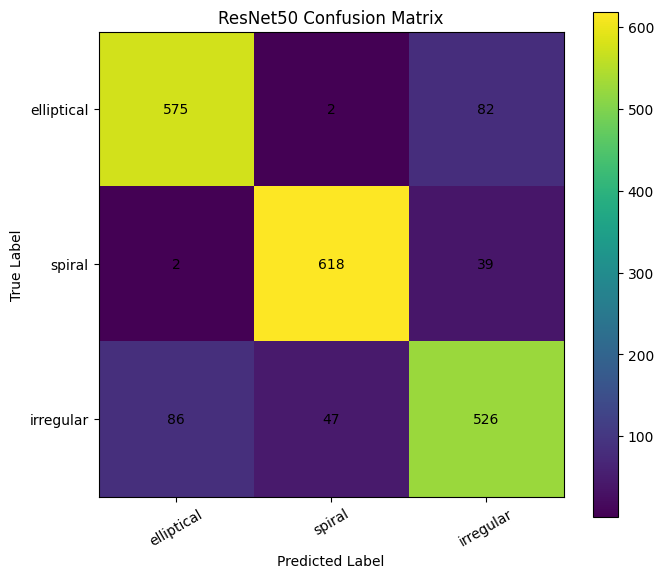

In [44]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(7, 6)
)

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(len(classes)),
    classes,
    rotation=30
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "ResNet50 Confusion Matrix"
)

for i in range(len(classes)):
    for j in range(len(classes)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

CONFUSION_PATH = os.path.join(
    RESULTS_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    CONFUSION_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 24. Combined Training History

The optimization histories from both training stages are combined into a single chronological record. Training and validation accuracy and loss are retained together with the transition between optimization stages. This representation supports direct analysis of convergence and changes in validation performance.

In [45]:
train_accuracy = (
    history_stage1.history["accuracy"]
    +
    history_stage2.history["accuracy"]
)

val_accuracy = (
    history_stage1.history["val_accuracy"]
    +
    history_stage2.history["val_accuracy"]
)

train_loss = (
    history_stage1.history["loss"]
    +
    history_stage2.history["loss"]
)

val_loss = (
    history_stage1.history["val_loss"]
    +
    history_stage2.history["val_loss"]
)

epochs = range(
    1,
    len(train_accuracy) + 1
)

fine_tune_start = (
    len(
        history_stage1.history["accuracy"]
    )
)

## 25. Training and Validation Accuracy

Training and validation accuracy are visualized across the complete optimization process. The transition between the two stages provides context for changes in model performance and allows the relationship between training progress and validation generalization to be examined.

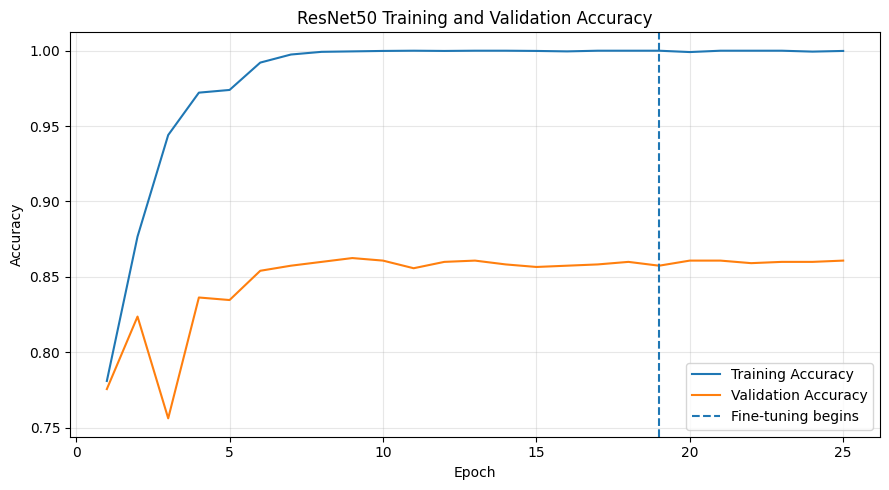

In [47]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    epochs,
    train_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracy,
    label="Validation Accuracy"
)

plt.axvline(
    fine_tune_start,
    linestyle="--",
    label="Fine-tuning begins"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "ResNet50 Training and Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

ACCURACY_GRAPH_PATH = os.path.join(
    RESULTS_DIR,
    "accuracy_curve.png"
)

plt.savefig(
    ACCURACY_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 26. Training and Validation Loss

Training and validation loss are tracked across both optimization stages. Their trajectories provide additional information about convergence, optimization stability, and potential divergence between training and validation performance.

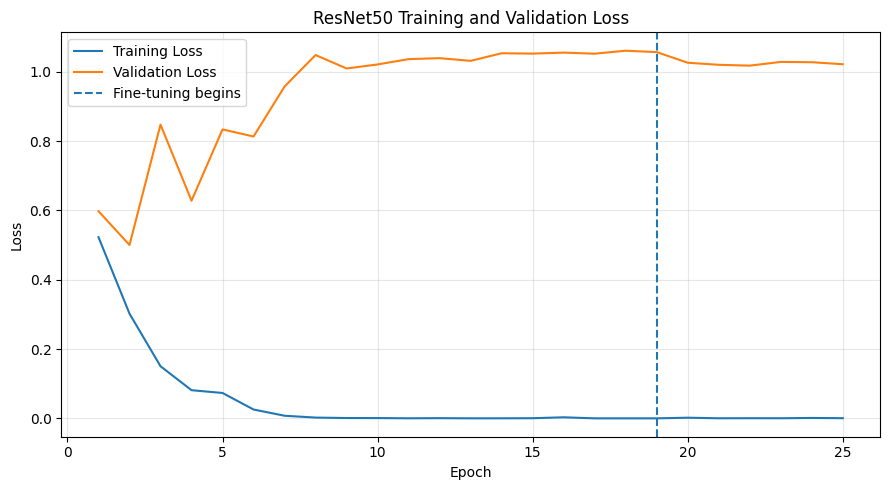

In [49]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    epochs,
    train_loss,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    label="Validation Loss"
)

plt.axvline(
    fine_tune_start,
    linestyle="--",
    label="Fine-tuning begins"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ResNet50 Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

LOSS_GRAPH_PATH = os.path.join(
    RESULTS_DIR,
    "loss_curve.png"
)

plt.savefig(
    LOSS_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 27. Training History Export

The combined epoch-level training history is exported in CSV format for reproducibility and further analysis. The saved record contains the principal training and validation metrics used to construct the learning curves.

In [50]:
history_df = pd.DataFrame({
    "epoch": list(epochs),
    "train_accuracy": train_accuracy,
    "validation_accuracy": val_accuracy,
    "train_loss": train_loss,
    "validation_loss": val_loss
})

history_path = os.path.join(
    RESULTS_DIR,
    "training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print(
    "Saved:",
    history_path
)

Saved: /kaggle/working/GalaxyZoo_ResNet50_Clean/results_7782/training_history.csv


## 28. Experiment Summary

The principal experiment configuration and evaluation results are consolidated into a machine-readable JSON summary. Training characteristics, validation performance, model parameters, and final metrics are recorded alongside the other generated artifacts.

In [52]:
import json

best_val_accuracy = max(stage1_best_val_acc, stage2_best_val_acc)
combined_val_accuracy = (
    history_stage1.history["val_accuracy"]
    + history_stage2.history["val_accuracy"]
)
best_epoch = int(np.argmax(combined_val_accuracy) + 1)
total_training_minutes = (stage1_time + stage2_time) / 60

summary = {
    "model": "ConvNeXt-Tiny full fine-tune",
    "dataset": "Galaxy Zoo 2",
    "classes": classes,
    "images_per_class": int(N_PER_CLASS),
    "input_size": list(IMG_SIZE),
    "batch_size": int(BATCH_SIZE),
    "threshold": float(THRESHOLD),
    "random_seed": int(SEED),
    "test_accuracy": float(accuracy),
    "test_accuracy_percent": float(accuracy * 100),
    "test_loss": float(test_loss),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "best_validation_accuracy": float(best_val_accuracy),
    "best_epoch": best_epoch,
    "training_time_minutes": float(total_training_minutes),
    "fine_tuned_layers": int(FINE_TUNE_LAYERS),
    "total_parameters": int(best_model.count_params()),
}

SUMMARY_PATH = RESULTS_DIR / "convnext_tiny_summary.json"
with open(SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=4)

print(json.dumps(summary, indent=4))


{
    "model": "ResNet50 — Fine-Tuned",
    "dataset": "Galaxy Zoo 2",
    "classes": [
        "elliptical",
        "spiral",
        "irregular"
    ],
    "images_per_class": 3295,
    "input_size": [
        256,
        256
    ],
    "batch_size": 32,
    "threshold": 0.8,
    "random_seed": 42,
    "test_accuracy": 0.8694992412746586,
    "test_accuracy_percent": 86.94992412746586,
    "test_loss": 0.8610866665840149,
    "macro_precision": 0.8689299050018772,
    "macro_recall": 0.8694992412746586,
    "macro_f1": 0.8691779378422074,
    "weighted_f1": 0.8691779378422075,
    "best_validation_accuracy": 0.8624472618103027,
    "best_epoch": 9,
    "training_time_minutes": 14.950281393527984,
    "fine_tuned_layers": 176,
    "total_parameters": 23593859
}


## 29. Test Prediction Records

Individual test predictions are stored together with filenames, class indices, predicted class names, confidence values, and correctness. This sample-level record supports detailed examination of model behavior and provides a reproducible basis for error analysis.

In [53]:
filenames = [os.path.basename(file_path) for file_path in test_file_paths]

prediction_df = pd.DataFrame({
    "filename": filenames,
    "true_class_index": y_true,
    "predicted_class_index": y_pred,
    "true_class": [classes[i] for i in y_true],
    "predicted_class": [classes[i] for i in y_pred],
    "confidence": np.max(prediction_probabilities, axis=1),
})

prediction_df["correct"] = (
    prediction_df["true_class"] == prediction_df["predicted_class"]
)

prediction_path = RESULTS_DIR / "test_predictions.csv"
prediction_df.to_csv(prediction_path, index=False)
display(prediction_df.head())


,filename,true_class_index,predicted_class_index,true_class,predicted_class,confidence,correct
0,1000.jpg,0,0,elliptical,elliptical,1.000000,True
1,100907.jpg,0,0,elliptical,elliptical,0.997379,True
2,101697.jpg,0,0,elliptical,elliptical,0.999834,True
3,10180.jpg,0,0,elliptical,elliptical,0.999974,True
4,101819.jpg,0,0,elliptical,elliptical,0.992277,True


## 30. High-Confidence Error Analysis

Incorrect test predictions are ordered by prediction confidence to identify cases where the model expresses strong but incorrect decisions. Such examples can provide insight into difficult morphology patterns and class boundaries that remain challenging for the classifier.

In [54]:
wrong_predictions = (
    prediction_df[
        prediction_df["correct"] == False
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
)

print(
    "Total mistakes:",
    len(wrong_predictions)
)

display(
    wrong_predictions.head(20)
)

Total mistakes: 258


,filename,true_class_index,predicted_class_index,true_class,predicted_class,confidence,correct
1049,25651.jpg,1,2,spiral,irregular,1.000000,False
1889,63008.jpg,2,0,irregular,elliptical,1.000000,False
1572,196693.jpg,2,0,irregular,elliptical,1.000000,False
399,254090.jpg,0,2,elliptical,irregular,1.000000,False
1868,53450.jpg,2,0,irregular,elliptical,1.000000,False
1223,60908.jpg,1,2,spiral,irregular,1.000000,False
476,35591.jpg,0,2,elliptical,irregular,1.000000,False
58,121326.jpg,0,2,elliptical,irregular,1.000000,False
709,11656.jpg,1,2,spiral,irregular,1.000000,False
703,113938.jpg,1,2,spiral,irregular,1.000000,False


## 31. Test-Time Augmentation Evaluation

Test-Time Augmentation (TTA) evaluates each test image together with multiple transformed versions and combines their predicted probabilities. Horizontal and vertical flips, together with 90° and 180° rotations, are used to assess prediction stability under the specified transformations. The resulting TTA performance provides an additional evaluation of model robustness.

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report

def predict_with_tta(model, test_ds):
    y_true = []
    all_batch_probs = []

    print("Calculating TTA predictions...")
    for images, labels in test_ds:
        y_true.extend(labels.numpy())
        
        aug_versions = [
            images,
            tf.image.flip_left_right(images),
            tf.image.flip_up_down(images),
            tf.image.rot90(images, k=1),
            tf.image.rot90(images, k=2)
        ]
        
        version_probs = [model.predict(aug_img, verbose=0) for aug_img in aug_versions]
        
        avg_probs = np.mean(version_probs, axis=0)
        all_batch_probs.append(avg_probs)

    all_probs = np.vstack(all_batch_probs)
    y_pred_tta = np.argmax(all_probs, axis=1)
    
    return np.array(y_true), y_pred_tta

y_true, y_pred_tta = predict_with_tta(model, test_dataset)

tta_acc = accuracy_score(y_true, y_pred_tta)
print(f"\n==========================================")
print(f"Test Accuracy with TTA: {tta_acc * 100:.2f}%")
print(f"==========================================\n")

print("--- Classification Report (TTA) ---")
print(classification_report(y_true, y_pred_tta, target_names=classes, digits=4))

Calculating TTA predictions...

Test Accuracy with TTA: 88.67%

--- Classification Report (TTA) ---
              precision    recall  f1-score   support

  elliptical     0.8786    0.8892    0.8839       659
      spiral     0.9495    0.9423    0.9459       659
   irregular     0.8323    0.8285    0.8304       659

    accuracy                         0.8867      1977
   macro avg     0.8868    0.8867    0.8867      1977
weighted avg     0.8868    0.8867    0.8867      1977


## 32. Validation Test-Time Augmentation Evaluation

The same Test-Time Augmentation procedure is applied to the validation set to characterize prediction behavior under the specified transformations. Accuracy and class-level metrics provide a complementary view of model performance during model development. Together with the held-out test evaluation, these results support a broader assessment of the ResNet50 classifier.

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report

def evaluate_val_with_tta(model, val_ds):
    y_true = []
    all_batch_probs = []

    print("Calculating TTA predictions for the validation set...")
    for images, labels in val_ds:
        y_true.extend(labels.numpy())
        
        aug_versions = [
            images,
            tf.image.flip_left_right(images),
            tf.image.flip_up_down(images),
            tf.image.rot90(images, k=1),
            tf.image.rot90(images, k=2)
        ]
        
        version_probs = [model.predict(aug_img, verbose=0) for aug_img in aug_versions]

        avg_probs = np.mean(version_probs, axis=0)
        all_batch_probs.append(avg_probs)

    all_probs = np.vstack(all_batch_probs)
    y_pred_val_tta = np.argmax(all_probs, axis=1)
    
    return np.array(y_true), y_pred_val_tta

y_val_true, y_val_pred_tta = evaluate_val_with_tta(model, validation_dataset)

val_acc_tta = accuracy_score(y_val_true, y_val_pred_tta)

print(f"\n==========================================")
print(f"TTA Validation Accuracy: {val_acc_tta * 100:.2f}%")
print(f"==========================================\n")

print("--- Validation Classification Report (TTA) ---")
print(classification_report(y_val_true, y_val_pred_tta, target_names=classes, digits=4))

Calculating TTA predictions for the validation set...

Validation Accuracy with TTA: 86.67%

--- Validation Classification Report (TTA) ---
              precision    recall  f1-score   support

  elliptical     0.8589    0.8785    0.8686       395
      spiral     0.9404    0.9190    0.9296       395
   irregular     0.8025    0.8025    0.8025       395

    accuracy                         0.8667      1185
   macro avg     0.8673    0.8667    0.8669      1185
weighted avg     0.8673    0.8667    0.8669      1185
